# A gentle introduction to Machine Learning

---
## What is AI? What is Machine Learning?

<p align="center">
  <img src="https://raw.githubusercontent.com/Hunter174/GentleIntroToML/main/assets/ai-ml-dl_bubbles.png" width="800"/>
</p>

**Artificial Intelligence (AI):** Systems that perform tasks requiring human-like intelligence (reasoning, decision-making, perception).

**Machine Learning (ML):** A subset of AI where systems learn patterns from data to make predictions or decisions.

**Deep Learning (DL):** A subset of ML using neural networks to model complex patterns in large datasets.

**Generative AI (GenAI):** Models that create new content (text, images, code) based on learned patterns.

---
## Types of Machine Learning

There are two main types:

### 1. Supervised Learning
We give the model inputs AND correct answers.

### 2. Unsupervised Learning
The model finds patterns without answers.

<p align="center">
  <img src="https://raw.githubusercontent.com/Hunter174/GentleIntroToML/main/assets/supervised-vs-unsupervised_learning.png" width="800"/>
</p>


---
# Problem 1: IRIS DATASET

We are going to visualize -> Train -> Predict
Given a popular tabular database
- Input: House size (square feet)
- Output: Price

We’ll train the model using example data.

In [57]:
from sklearn.datasets import load_iris

# Load the dataset
iris_data = load_iris(as_frame=True)
df = iris_data.frame

# Load the first n=5 samples
display(df.head())
display(df.describe())

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
count,150.000000,150.000000,150.000000,150.000000,150.000000
mean,5.843333,3.057333,3.758000,1.199333,1.000000
std,0.828066,0.435866,1.765298,0.762238,0.819232
min,4.300000,2.000000,1.000000,0.100000,0.000000
25%,5.100000,2.800000,1.600000,0.300000,0.000000
50%,5.800000,3.000000,4.350000,1.300000,1.000000
75%,6.400000,3.300000,5.100000,1.800000,2.000000
max,7.900000,4.400000,6.900000,2.500000,2.000000


In [58]:
from sklearn.preprocessing import StandardScaler

# Features and target
X = df.drop(columns=["target"])
y = df["target"]

# Standardize features (important for PCA)
X = StandardScaler().fit_transform(X)

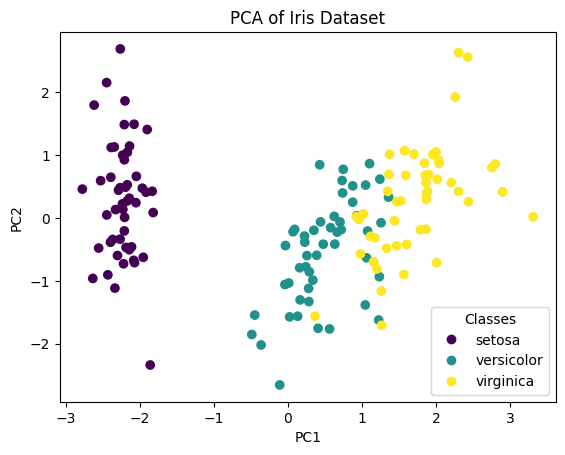

In [59]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

# we are going to "Explore" the data to understand what it looks like
# PCA → 2 components
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X)

# Plot
plt.figure()

scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis"
)

# Legend with class names
handles, _ = scatter.legend_elements()
labels = iris_data.target_names
plt.legend(handles, labels, title="Classes")

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of Iris Dataset")

plt.show()

 # Why do we need a train/test split?

When we train a model, it learns patterns from the data we give it.

If we evaluate the model on the **same data it was trained on**, it can appear to perform very well—even if it has simply memorized the data.

To properly measure performance, we split the data into:

- **Training set** → used to train the model
- **Test set** → used to evaluate how well the model generalizes to new, unseen data

---

# Key Idea

> We test on data the model has never seen before to estimate real-world performance.

In [60]:
# Split the data into a train set and a test set
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2, # 20% for testing
    random_state=42 # Ensures reproducibility
)

# Logistic Regression (Classification)

Logistic regression is used for **classification problems**.
Instead of predicting a number, it predicts the **probability of a class**.

<p align="center">
  <img src="https://raw.githubusercontent.com/Hunter174/GentleIntroToML/main/assets/what-is-logistic-regression.png" width="400"/>
</p>



For an interactive, visual explanation, see:
🔗 https://mlu-explain.github.io/logistic-regression/

---


# One-vs-Rest (OvR) for Multiple Classes
How do we handle more than two classes?

<p align="center">
  <img src="https://raw.githubusercontent.com/Hunter174/GentleIntroToML/main/assets/what-is-ovr.png" width="400"/>
</p>

**One-vs-Rest (OvR)** breaks a multi-class problem into multiple binary problems.

For each class:
- Treat that class as **“positive”**
- Treat all other classes as **“negative”**
- Train a separate model

Example (Iris with 3 classes):
- Model 1: Setosa vs Not Setosa
- Model 2: Versicolor vs Not Versicolor
- Model 3: Virginica vs Not Virginica

Each model outputs a probability.
We select the class with the **highest probability**.

---

# Key Idea

> Multi-class classification = multiple binary classifiers working together

In [61]:
# Logistic Regression (OvR - One vs Rest)
from sklearn.linear_model import LogisticRegression

# Initialize model
model = LogisticRegression(max_iter=200)

# Train the model
model.fit(X_train, y_train)

# Evaluate
accuracy = model.score(X_test, y_test)
print("Accuracy:", accuracy)

Accuracy: 1.0


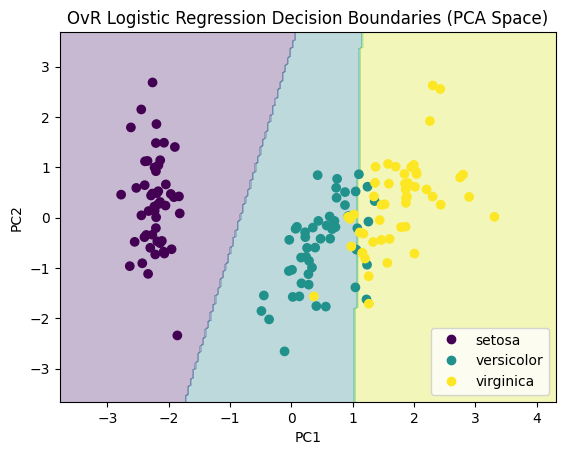

In [62]:
#@title Visualize decision boundaries (in PCA space)
#@hide_code

import numpy as np
import matplotlib.pyplot as plt

# --- Step 2: Train model on PCA data ---
model = LogisticRegression(max_iter=200)
model.fit(X_pca, y)

# --- Step 3: Create mesh grid ---
x_min, x_max = X_pca[:, 0].min() - 1, X_pca[:, 0].max() + 1
y_min, y_max = X_pca[:, 1].min() - 1, X_pca[:, 1].max() + 1

xx, yy = np.meshgrid(
    np.linspace(x_min, x_max, 200),
    np.linspace(y_min, y_max, 200)
)

# --- Step 4: Predict over grid ---
Z = model.predict(np.c_[xx.ravel(), yy.ravel()])
Z = Z.reshape(xx.shape)

# --- Step 5: Plot ---
plt.figure()

# Decision regions
plt.contourf(xx, yy, Z, alpha=0.3, cmap="viridis")

# Original points
scatter = plt.scatter(
    X_pca[:, 0],
    X_pca[:, 1],
    c=y,
    cmap="viridis"
)

# Legend
handles, _ = scatter.legend_elements()
plt.legend(handles, ["setosa", "versicolor", "virginica"])

plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("OvR Logistic Regression Decision Boundaries (PCA Space)")

plt.show()

---

# Random Forest (Classification)

Random Forests are used for **classification problems and regression problems**.
It is a collection of CART trees randomly sample accross all features

In [63]:
#@title Titanic Setup (Raw Data)

import seaborn as sns

df = sns.load_dataset("titanic")

# Keep a mix of numeric + categorical
features = ["pclass", "sex", "age", "fare", "embarked"]
target = "survived"

X = df[features]
y = df[target]

display(X.head())

,pclass,sex,age,fare,embarked
0,3,male,22.0,7.2500,S
1,1,female,38.0,71.2833,C
2,3,female,26.0,7.9250,S
3,1,female,35.0,53.1000,S
4,3,male,35.0,8.0500,S


In [80]:
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.impute import SimpleImputer

# Separate feature types
numeric_features = ["age", "fare"]
categorical_features = ["sex", "embarked", "pclass"]

# Numeric pipeline
numeric_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="mean"))
])

# Categorical pipeline
categorical_transformer = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("onehot", OneHotEncoder(handle_unknown="ignore"))
])

# Combine everything
preprocessor = ColumnTransformer(
    transformers=[
        ("num", numeric_transformer, numeric_features),
        ("cat", categorical_transformer, categorical_features)
    ]
)

In [81]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import train_test_split

# Train/test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Full pipeline
model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("classifier", RandomForestClassifier(n_estimators=100, random_state=42))
])

# Train
model.fit(X_train, y_train)

# Evaluate
print("Accuracy:", model.score(X_test, y_test))

Accuracy: 0.7932960893854749


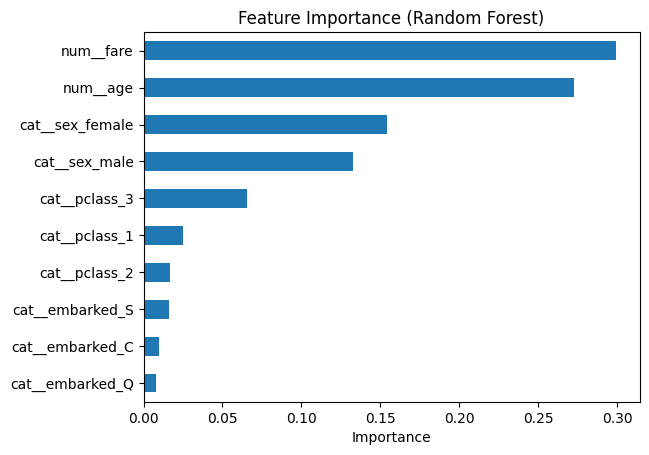

In [82]:
#@title what features are the most important?

# Feature importance (after preprocessing)

import pandas as pd
import matplotlib.pyplot as plt

# Get feature names after preprocessing
feature_names = model.named_steps["preprocessor"].get_feature_names_out()

# Get importances
importances = model.named_steps["classifier"].feature_importances_

# Create series
feat_imp = pd.Series(importances, index=feature_names)

# Plot
feat_imp.sort_values().plot(kind="barh")

plt.title("Feature Importance (Random Forest)")
plt.xlabel("Importance")
plt.show()

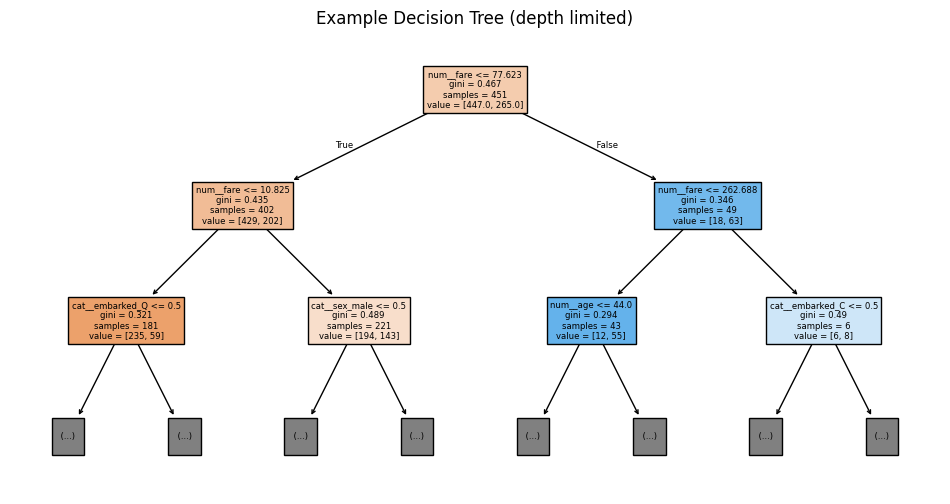

In [83]:
#@title Visualize a single tree

from sklearn.tree import plot_tree
import matplotlib.pyplot as plt

# Grab one tree from the forest
tree = model.named_steps["classifier"].estimators_[0]

plt.figure(figsize=(12, 6))
plot_tree(tree, max_depth=2, feature_names=feature_names, filled=True)
plt.title("Example Decision Tree (depth limited)")
plt.show()

---
what is a neural network?

In [88]:
# Neural Network (MLP)

from sklearn.neural_network import MLPClassifier
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import Pipeline

# Full pipeline
mlp_model = Pipeline(steps=[
    ("preprocessor", preprocessor),
    ("scaler", StandardScaler(with_mean=False)),  # important for sparse one-hot output
    ("classifier", MLPClassifier(
    hidden_layer_sizes=(64, 32, 16),
    activation="relu",
    alpha=0.001,
    max_iter=1000,
    random_state=42
    ))
])

# Train
mlp_model.fit(X_train, y_train)

# Evaluate
print("MLP Accuracy:", mlp_model.score(X_test, y_test))

MLP Accuracy: 0.8100558659217877


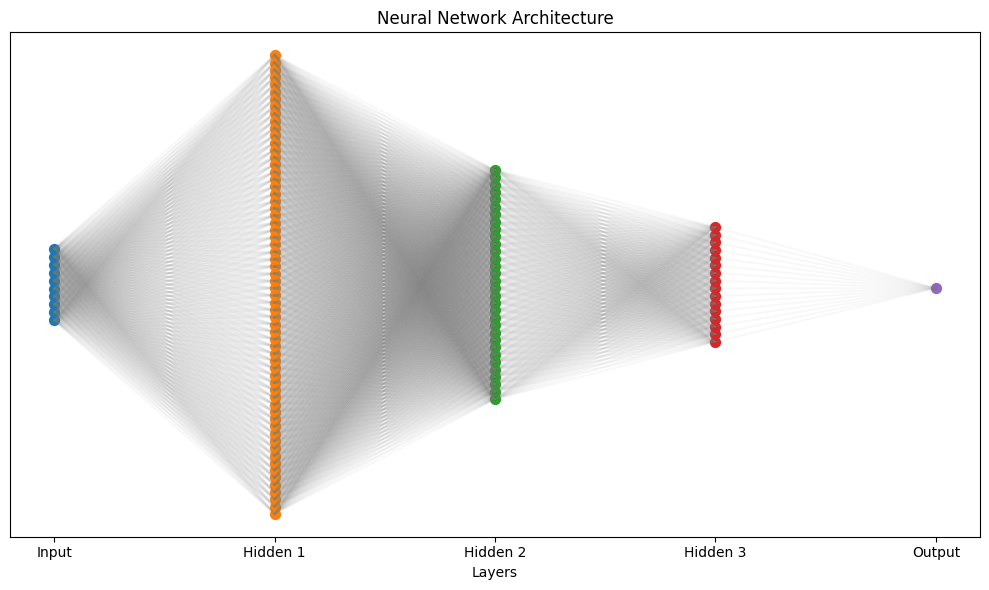

In [91]:
#@title Why are these models called black box models?

import matplotlib.pyplot as plt
import numpy as np

# Get layer sizes
mlp = mlp_model.named_steps["classifier"]
layer_sizes = [mlp.n_features_in_] + list(mlp.hidden_layer_sizes) + [mlp.n_outputs_]

plt.figure(figsize=(10, 6))

max_neurons = max(layer_sizes)

# --- Plot nodes (centered vertically) ---
for i, layer_size in enumerate(layer_sizes):
    y_positions = np.linspace(
        (max_neurons - layer_size) / 2,
        (max_neurons + layer_size) / 2,
        layer_size
    )
    x_positions = [i] * layer_size

    plt.scatter(x_positions, y_positions, s=50)

# --- Draw connections (lighter + cleaner) ---
for i in range(len(layer_sizes) - 1):
    layer1 = layer_sizes[i]
    layer2 = layer_sizes[i + 1]

    y1 = np.linspace((max_neurons - layer1) / 2,
                     (max_neurons + layer1) / 2,
                     layer1)

    y2 = np.linspace((max_neurons - layer2) / 2,
                     (max_neurons + layer2) / 2,
                     layer2)

    for j in range(layer1):
        for k in range(layer2):
            plt.plot([i, i+1], [y1[j], y2[k]], alpha=0.05, color="gray")

# --- Labels (dynamic) ---
labels = ["Input"] + \
         [f"Hidden {i+1}" for i in range(len(layer_sizes) - 2)] + \
         ["Output"]

plt.xticks(range(len(layer_sizes)), labels)
plt.yticks([])

plt.title("Neural Network Architecture")
plt.xlabel("Layers")

plt.tight_layout()
plt.show()

---
# Convolutional Neural Network

How do we process images?


29515/29515 ━━━━━━━━━━━━━━━━━━━━ 0s 2us/step
26421880/26421880 ━━━━━━━━━━━━━━━━━━━━ 1s 0us/step
5148/5148 ━━━━━━━━━━━━━━━━━━━━ 0s 0s/step
4422102/4422102 ━━━━━━━━━━━━━━━━━━━━ 0s 0us/step


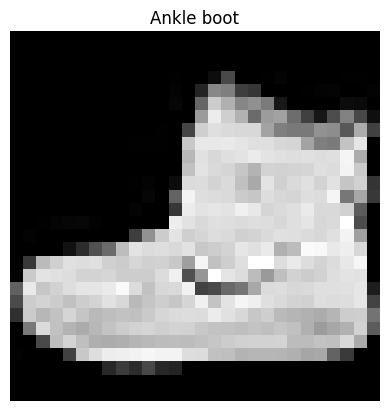

In [100]:
#@title Load Fashion MNIST

import tensorflow as tf
import matplotlib.pyplot as plt

(X_train, y_train), (X_test, y_test) = tf.keras.datasets.fashion_mnist.load_data()

class_names = [
    "T-shirt", "Trouser", "Pullover", "Dress", "Coat",
    "Sandal", "Shirt", "Sneaker", "Bag", "Ankle boot"
]

# Normalize
X_train = X_train / 255.0
X_test = X_test / 255.0

# Add channel dimension
X_train = X_train.reshape(-1, 28, 28, 1)
X_test = X_test.reshape(-1, 28, 28, 1)

# Show example
plt.imshow(X_train[0].reshape(28,28), cmap="gray")
plt.title(class_names[y_train[0]])
plt.axis("off")
plt.show()

In [101]:
#@title Train CNN (Fashion MNIST)

from tensorflow.keras import layers, models

model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(28,28,1)),
    layers.MaxPooling2D(2,2),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(2,2),

    layers.Flatten(),
    layers.Dense(64, activation='relu'),
    layers.Dense(10, activation='softmax')
])

model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

model.fit(X_train, y_train, epochs=5, validation_split=0.1)

C:\Users\7568316\AppData\Local\Programs\Python\Python312\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.8176 - loss: 0.5001 - val_accuracy: 0.8652 - val_loss: 0.3703
Epoch 2/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8763 - loss: 0.3373 - val_accuracy: 0.8752 - val_loss: 0.3329
Epoch 3/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 12s 7ms/step - accuracy: 0.8955 - loss: 0.2875 - val_accuracy: 0.8952 - val_loss: 0.2842
Epoch 4/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 11s 6ms/step - accuracy: 0.9063 - loss: 0.2539 - val_accuracy: 0.9003 - val_loss: 0.2744
Epoch 5/5
1688/1688 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.9159 - loss: 0.2277 - val_accuracy: 0.9015 - val_loss: 0.2748


In [98]:
#@title Evaluate

loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

63/63 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7500 - loss: 0.5119
Test Accuracy: 0.75


In [99]:
#@title Upload Image and Predict

from google.colab import files
from PIL import Image

uploaded = files.upload()

for filename in uploaded.keys():
    img = Image.open(filename).resize((32,32))
    img_array = np.array(img) / 255.0

    img_array = img_array.reshape(1,32,32,3)

    pred = model.predict(img_array)

    print("Prediction:", "Dog 🐶" if pred[0][0] > 0.5 else "Cat 🐱")

    plt.imshow(img)
    plt.axis("off")
    plt.show()

ModuleNotFoundError: No module named 'google.colab'